# Laboratório 11: Detecção e Tratamento Integrado de Outliers
**Disciplina:** Extração e Preparação de Dados (IBM8915)
**Professor:** Luís Aramis

**Objetivo:** Atuar como um Auditor de Risco. Você vai aprender a diagnosticar anomalias univariadas usando Boxplots e a regra do IQR, tratar esses extremos de forma segura com `clip()` (Winsorization) e, por fim, utilizar Inteligência Artificial (Isolation Forest) para encontrar fraudes ocultas no cruzamento de múltiplas variáveis.

In [1]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Simulando um dataset de E-commerce com anomalias plantadas
np.random.seed(42)
n_linhas = 1000

df_risco = pd.DataFrame({
    'ID_Cliente': range(1, n_linhas + 1),
    'Idade_Conta': np.random.randint(10, 3650, n_linhas), # Dias
    'Receita': np.random.exponential(scale=500, size=n_linhas) + 50, 
    'Ticket_Medio': np.random.normal(150, 40, n_linhas)
})

# Plantando Outliers Univariados (O "Elon Musk")
df_risco.loc[990:995, 'Receita'] = 50000

# Plantando Outliers Multivariados (Fraudes Complexas)
# Contas recém-criadas (10 dias) com Ticket Médio absurdamente alto, 
# mas que não rompem o limite univariado isoladamente.
df_risco.loc[996:999, 'Idade_Conta'] = 10
df_risco.loc[996:999, 'Ticket_Medio'] = 500

display(df_risco.tail(15))

,ID_Cliente,Idade_Conta,Receita,Ticket_Medio
985,986,780,198.235480,123.520713
986,987,3387,1697.431486,167.035488
987,988,277,380.384186,150.765911
988,989,1994,869.929359,124.340524
989,990,1087,449.505625,169.514891
990,991,245,50000.000000,222.173924
991,992,398,50000.000000,142.363848
992,993,3047,50000.000000,178.790318
993,994,772,50000.000000,98.269082
994,995,1858,50000.000000,111.742545


## Parte 1: O Raio-X Visual (Boxplot)
Antes de fazermos matemática, precisamos enxergar o problema.
**Tarefa:** Plote um gráfico de caixa (`sns.boxplot`) para a coluna `Receita`. Identifique visualmente a caixa (onde estão 50% dos dados) e os pontos que representam os outliers (fora dos bigodes).

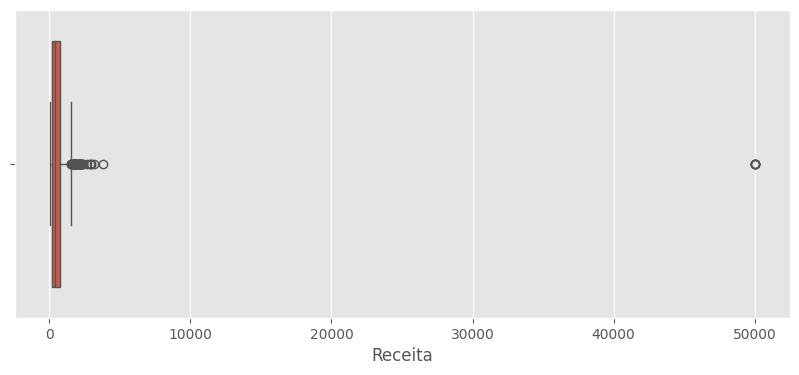

In [3]:
# ESCREVA SEU CÓDIGO AQUI
# Plote o boxplot da coluna 'Receita' usando seaborn
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_risco['Receita'])
plt.show()

## Parte 2: O Cálculo das Cercas (Regra do IQR)
O gráfico nos mostrou que temos valores extremos, mas onde exatamente começa a anomalia? 
A regra do Intervalo Interquartil (IQR) dita que:
1. Calculamos o Q1 (Percentil 25%) e o Q3 (Percentil 75%).
2. Subtraímos um do outro para achar o IQR (`Q3 - Q1`).
3. O Limite Superior é `Q3 + 1.5 * IQR`. Tudo acima disso é outlier matemático!

In [4]:
# ESCREVA SEU CÓDIGO AQUI

# 1. Calcule Q1 e Q3 da coluna 'Receita' usando o método .quantile()
Q1 = df_risco['Receita'].quantile(0.25)
Q3 = df_risco['Receita'].quantile(0.75)

# 2. Calcule o IQR
IQR = Q3 - Q1

# 3. Defina o Limite Superior
limite_superior = Q3 + 1.5 * IQR

print(f"O Limite Máximo Aceitável para a Receita é: R$ {limite_superior:.2f}")

O Limite Máximo Aceitável para a Receita é: R$ 1548.51


## Parte 3: A Cirurgia de Clipping
Se usarmos um `dropna()` e deletarmos os milionários da base, perderemos dados valiosos de `Idade_Conta` e `Ticket_Medio` que pertencem a eles. 

**A Solução:** Vamos usar a técnica de *Winsorization*.
**Sua Tarefa:** Use o método nativo `.clip()` do Pandas na coluna `Receita`. Defina o parâmetro `upper` como o `limite_superior` que você acabou de calcular. Salve isso em uma nova coluna chamada `Receita_Tratada`.

In [5]:
# ESCREVA SEU CÓDIGO AQUI

# Aplique o .clip() para amassar a cauda longa
df_risco['Receita_Tratada'] = df_risco['Receita'].clip(upper=limite_superior)

# Prove que funcionou verificando o novo valor máximo da coluna tratada
print("Novo Máximo:", df_risco['Receita_Tratada'].max())

Novo Máximo: 1548.5103227819072


## Parte 4: A Visão Multivariada
Nós resolvemos a Receita, mas e as fraudes ocultas? Existem clientes com contas recém-criadas gastando fortunas de uma só vez, o que burla o IQR isolado.

Vamos invocar o Scikit-Learn e a classe `IsolationForest` para auditar nossa base cruzando 3 colunas simultaneamente.

In [6]:
# 1. Isole as features que vão alimentar o modelo de IA
features = ['Idade_Conta', 'Receita_Tratada', 'Ticket_Medio']
X = df_risco[features]

# 2. Instancie o Detetive (Isolation Forest) esperando 1% de fraudes (contamination=0.01)
detector = IsolationForest(contamination=0.01, random_state=42)

# 3. Encaixe o modelo e faça as predições (fit_predict)
df_risco['Outlier_ML'] = detector.fit_predict(X)

# Faça um value_counts da nova coluna 'Outlier_ML' para ver quantos '-1' foram encontrados!
print(df_risco['Outlier_ML'].value_counts())

Outlier_ML
 1    990
-1     10
Name: count, dtype: int64


## Parte 5: O Desafio do Auditor (Para Casa)
O modelo Isolation Forest avaliou múltiplas dimensões e marcou os dados normais como `1` e as anomalias (fraudes) como `-1`.

Como analista de risco, seu diretor pediu um relatório comprovando o porquê o modelo barrou essas contas.

**Sua Tarefa (Missão de Casa):**
1. **Isolar:** Crie um filtro no `df_risco` para visualizar apenas os clientes classificados como `-1`.
2. **Comparar Perfis:** Use `df_risco.groupby('Outlier_ML').mean()` para comparar as médias de `Idade_Conta`, `Receita_Tratada` e `Ticket_Medio` dos clientes normais (1) vs anômalos (-1).
3. **Visão Executiva (Gráfico):** Crie um gráfico de dispersão (`sns.scatterplot`) colocando `Idade_Conta` no eixo X e `Ticket_Medio` no eixo Y. Use o parâmetro `hue='Outlier_ML'` para colorir os pontos e evidenciar visualmente as fraudes detectadas isoladas do comportamento padrão.
4. **Conclusão Auditorial:** Escreva qual é o padrão suspeito (o modus operandi) dessa fraude complexa.

,ID_Cliente,Idade_Conta,Receita,Ticket_Medio,Receita_Tratada,Outlier_ML
19,20,3390,1355.831382,238.420920,1355.831382,-1
23,24,3495,2006.826549,253.188374,1548.510323,-1
526,527,14,1497.780802,107.852703,1497.780802,-1
747,748,2992,1073.851776,275.509941,1073.851776,-1
861,862,3594,1408.104327,199.445229,1408.104327,-1
908,909,2940,1939.931556,47.506654,1548.510323,-1
996,997,10,179.437033,500.000000,179.437033,-1
997,998,10,169.157047,500.000000,169.157047,-1
998,999,10,522.063532,500.000000,522.063532,-1
999,1000,10,314.688716,500.000000,314.688716,-1


,Idade_Conta,Receita_Tratada,Ticket_Medio
Outlier_ML,,,
-1,1646.500000,961.793526,312.192382
1,1862.872727,518.487022,151.071207


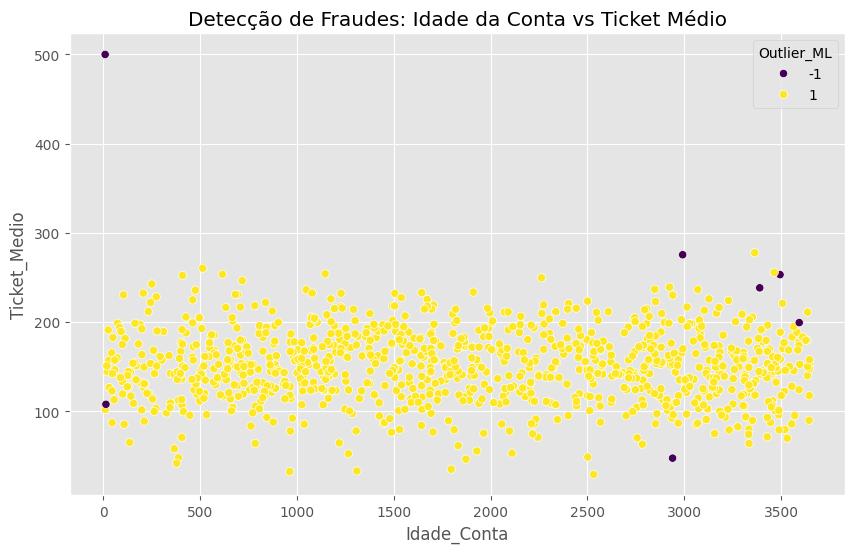

In [7]:
# ESCREVA SEU CÓDIGO AQUI

# 1. Isolar anomalias
anomalias = df_risco[df_risco['Outlier_ML'] == -1]
display(anomalias)

# 2. Comparar Médias (groupby)
display(df_risco.groupby('Outlier_ML')[['Idade_Conta', 'Receita_Tratada', 'Ticket_Medio']].mean())

# 3. Gráfico (Scatterplot de cruzamento Idade x Ticket com hue=Outlier_ML)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_risco, x='Idade_Conta', y='Ticket_Medio', hue='Outlier_ML', palette='viridis')
plt.title("Detecção de Fraudes: Idade da Conta vs Ticket Médio")
plt.show()

# 4. Responda: Qual o padrão dessas contas barradas?
# O padrão suspeito (modus operandi) são contas extremamente recentes (Idade_Conta próxima a 10 dias) 
# com um Ticket_Medio muito elevado (próximo a 500), caracterizando possíveis fraudes de 'conta laranja'.

## Parte 6: Desafio com Dados Reais (Kaggle)
Até agora usamos dados simulados. Como seria aplicar isso no mundo real?

Vamos usar um dataset famoso do Kaggle: **Credit Card Fraud Detection**.
Ele contém transações de cartões de crédito, onde a classe positiva (fraude) é altamente desbalanceada.
Link do Dataset no Kaggle: [Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud)

Baixaremos uma amostra ou usaremos um link raw disponível no GitHub.

In [8]:
# Carregando o dataset real de fraudes em cartão de crédito (Kaggle)
# Vamos usar um link direto (RAW), pode demorar alguns segundos devido ao tamanho do arquivo original.
url_kaggle = 'https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv'

# Lendo apenas as primeiras 50 mil linhas para não sobrecarregar a memória nesta aula
df_kaggle = pd.read_csv(url_kaggle, nrows=50000)

display(df_kaggle.head())
print("Formato dos dados: ", df_kaggle.shape)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Formato dos dados:  (50000, 31)


### Exercício 1: Explorando a Distribuição Visual
As variáveis `V1` a `V28` são o resultado de uma transformação PCA (para manter a privacidade). As únicas variáveis originais são `Time` e `Amount` (Valor da Transação).

**Sua Tarefa:**
1. Crie um Boxplot usando Seaborn para a variável `Amount`.
2. Analise: Pelo aspecto visual da cauda (pontos fora da caixa), o método do IQR (que corta os excessos) parece uma boa ideia para descobrir anomalias nesta coluna isolada?

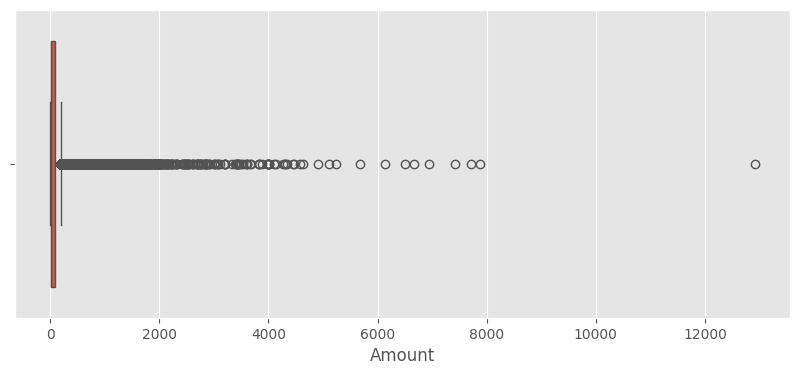

In [9]:
# ESCREVA SEU CÓDIGO AQUI
# Plote o Boxplot da coluna 'Amount'
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_kaggle['Amount'])
plt.show()

### Exercício 2: O Custo do Falso Positivo na Regra do IQR
Muitas fraudes podem ocorrer em transações de alto valor. Se usarmos a matemática do IQR cegamente, podemos estar punindo (falso positivo) clientes legítimos gastando muito. 
No dataset do Kaggle, a coluna `Class` vale 1 para fraude e 0 para transação normal.

**Sua Tarefa:**
1. Calcule o `limite_superior` para a coluna `Amount` usando a Regra do IQR (Q3 + 1.5 * IQR).
2. Descubra: Das transações que ficaram **acima** desse limite superior, quantas eram transações totalmente **Legítimas** (`Class == 0`)?

In [10]:
# ESCREVA SEU CÓDIGO AQUI

# 1. Calcule o Limite Superior
Q1 = df_kaggle['Amount'].quantile(0.25)
Q3 = df_kaggle['Amount'].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5 * IQR

# 2. Filtre e conte as legítimas (Class == 0) que passaram do lim_sup
legitimas_acima = df_kaggle[(df_kaggle['Amount'] > lim_sup) & (df_kaggle['Class'] == 0)]
print(f"O Limite Superior do IQR é: {lim_sup}")
print(f"Transações legítimas acima do limite: {len(legitimas_acima)}")

O Limite Superior do IQR é: 201.68375
Transações legítimas acima do limite: 5188


### Exercício 3: O Detetive de IA Multivariado (Isolation Forest)
Já que uma variável só não resolveu, vamos invocar o modelo de Machine Learning ensinando-o a ler 29 variáveis simultaneamente.

**Sua Tarefa:**
1. Isole a base de aprendizado ignorando as colunas `Class` (pois o detector é não-supervisionado) e `Time`: 
`X = df_kaggle.drop(columns=['Class', 'Time'])`
2. Instancie e treine o `IsolationForest` com `contamination=0.01` e `random_state=42`.
3. Salve o `.fit_predict(X)` em uma nova coluna `Outlier_ML` no dataset original.
4. Veja na prática a eficácia: Faça um cruzamento (`pd.crosstab`) da nossa predição `Outlier_ML` com a realidade `Class` do Kaggle!

In [11]:
# ESCREVA SEU CÓDIGO AQUI

X = df_kaggle.drop(columns=['Class', 'Time'])
detector_kaggle = IsolationForest(contamination=0.01, random_state=42)
df_kaggle['Outlier_ML'] = detector_kaggle.fit_predict(X)

# Mostre a confusão:
display(pd.crosstab(df_kaggle['Outlier_ML'], df_kaggle['Class']))

Class,0,1
Outlier_ML,,
-1,402,98
1,49450,50
